In [1]:
import HTSeq
import pysam
import numpy as np
import os

from price2.reference_annotation import ReferenceAnnotation
from price2.locus import Locus
from price2.cleavage_model import CleavageModel
from price2.ribo_seq_alignment import RiboSeqAlignment
from price2.ribo_seq_run import RiboSeqRun

from matplotlib import pyplot as plt

In [2]:
class ORFActivityEstimator:
    ribo_seq_runs: list[RiboSeqRun]
    #cms: list[CleavageModel]
    #alignments: list[HTSeq.BAM_Reader]
    alignment: HTSeq.BAM_Reader
    overlap_likelihood_ratio_threshold: float
    delta_cutoff: float
    maxiter: int
    loci_intervals: HTSeq.GenomicArray
    loci_set: set[Locus]
    chr_order: list[str]
    
    def __init__(
            self,
            read_alignments_dir: str,
            reference_annotation: ReferenceAnnotation,
            overlap_likelihood_ratio_threshold: float=.01,
            delta_cutoff: float=1,
            maxiter: int=100,
            cleavage_model: CleavageModel=None,
    ) -> None:

        self.ribo_seq_runs = []
        self.chr_order = None
        # iterate bam files in read_alignments_dir
        for bam_file in os.listdir(read_alignments_dir):
            if bam_file.endswith(".bam"):
                if not self.chr_order:
                    bam_reader = HTSeq.BAM_Reader(os.path.join(read_alignments_dir, bam_file))
                    self.chr_order = [x['SN'] for x in bam_reader.get_header_dict()['SQ']]
                self.ribo_seq_runs.append(
                    RiboSeqRun(bam_file.split('.')[0], 
                               read_alignments_dir, 
                               reference_annotation,
                               cleavage_model=cleavage_model,
                               )
                )


        self.overlap_likelihood_ratio_threshold = overlap_likelihood_ratio_threshold
        self.delta_cutoff = delta_cutoff
        self.maxiter = maxiter
        loci_intervals_binary = HTSeq.GenomicArray("auto", stranded=True, storage="step", typecode="b")
        for transcript in reference_annotation.transcripts.values():
            loci_intervals_binary[transcript.iv] = True
        self.loci_intervals = HTSeq.GenomicArray("auto", stranded=True, storage="step", typecode="O")
        self.loci_set = set()
        
        connected_loci = {'+':[], '-':[]}
        for iv, step in loci_intervals_binary.steps():
            if step:
                if not connected_loci[iv.strand]:
                    connected_loci[iv.strand].append(iv)
                    continue
                if connected_loci[iv.strand][-1].chrom == iv.chrom\
                        and connected_loci[iv.strand][-1].end + 50 > iv.start:
                    connected_loci[iv.strand].append(iv)
                else:
                    connected_iv = HTSeq.GenomicInterval(
                        connected_loci[iv.strand][0].chrom, 
                        connected_loci[iv.strand][0].start, 
                        connected_loci[iv.strand][-1].end, 
                        iv.strand
                        )
                    locus = Locus(connected_iv, reference_annotation.transcript_intervals)
                    self.loci_intervals[connected_iv] = locus
                    self.loci_set.add(locus)
                    connected_loci[iv.strand] = [iv]
        for strand in ['+', '-']:
            try:
                connected_iv = HTSeq.GenomicInterval(
                    connected_loci[strand][0].chrom, 
                    connected_loci[strand][0].start, 
                    connected_loci[strand][-1].end, 
                    strand
                    )
                locus = Locus(connected_iv, reference_annotation.transcript_intervals)
                self.loci_intervals[connected_iv] = locus
                self.loci_set.add(locus)
            except IndexError:
                pass
                



In [3]:
directory = '/projects/viro/maidhof/price2/orf_deconvolution_development/data_advanced/runs_debug'
gtf_path = f'{directory}/orf_deconvolution.gtf'
fasta_path = f'{directory}/generated_data/orf_deconvolution.fasta'
bam_dir = f'{directory}/generated_data'

ra = ReferenceAnnotation(gtf_path)
genome = dict((s.name, s) for s in HTSeq.FastaReader(fasta_path))

pl = np.loadtxt(f'{directory}/upstream_cleavage_model')
pl = pl / pl.sum()
pr = np.loadtxt(f'{directory}/downstream_cleavage_model')
pr = pr / pr.sum()
u = .1
cm = CleavageModel(pl, pr, u)

In [4]:
oae = ORFActivityEstimator(
    bam_dir,
    ra,
    cleavage_model=cm,
)
oae.loci_set


{Locus(chr2:[999,5000)/+)}

In [5]:
loc = list(oae.loci_set)[0]
loc

Locus(chr2:[999,5000)/+)

In [6]:
# iterate chromosomes
for chr in oae.chr_order:
    next_chr = False
    current_loci = {'+': None, '-': None}

    ivs_steps = {
        '+': oae.loci_intervals[HTSeq.GenomicInterval(chr, 0, 1e10, "+")].steps(),
        '-': oae.loci_intervals[HTSeq.GenomicInterval(chr, 0, 1e10, "-")].steps(),
    }
    
    # iterate loci
    while True:
        for strand in ['+', '-']:
            if not current_loci[strand]:
                try:
                    while not (tmp:=next(ivs_steps[strand])[1]):
                        pass
                    current_loci[strand] = tmp
                    current_loci[strand].activate(genome, oae.ribo_seq_runs)
                except StopIteration:
                    continue
        if not current_loci['+'] and not current_loci['-']:
            break
        # iterate ribo_seq_runs
        for run in oae.ribo_seq_runs:
            
            # iterate alignments
            for alignment in run.bam_reader:

                if alignment.optional_field('NH') > 1:
                    continue
                aln = RiboSeqAlignment(alignment)
                strand = aln.alignment.iv.strand
                if not current_loci[strand]:
                    continue

                if aln.alignment.iv.chrom != chr: # end of chromosome (in this run)
                    next_chr = True
                    break
                
                if current_loci[strand].iv.overlaps(aln.alignment.iv):
                    current_loci[strand].add_ribo_seq_alignment(aln, run)
                elif current_loci[strand].iv.end < aln.alignment.iv.start:
                    break

        if next_chr:
            if current_loci['+']:
                current_loci['+'].run_orf_deconvolution(oae.ribo_seq_runs)
            if current_loci['-']:
                current_loci['-'].run_orf_deconvolution(oae.ribo_seq_runs)
            break
        
        if not current_loci['+'] and not current_loci['-']:
            break
        elif not current_loci['+']:
            strand = '-'
        elif not current_loci['-']:
            strand = '+'
        elif current_loci['+'].iv.end < current_loci['-'].iv.end:
            strand = '+'
        else:
            strand = '-'
        current_loci[strand].run_orf_deconvolution(oae.ribo_seq_runs)
        current_loci[strand] = None




{1: 2301, 2: 7681}
{1: 2301, 2: 7681}
{1: 2301, 2: 7681}
{1: 2301, 2: 7681}
{1: 2301, 2: 7681}
{1: 2301, 2: 7681}
{1: 2301, 2: 7681}
{1: 2301, 2: 7681}
{1: 2301, 2: 7681}
{1: 2301, 2: 7681}
{1: 2301, 2: 7681}
{1: 2301, 2: 7681}
{1: 2301, 2: 7681}
{1: 2301, 2: 7681}
{1: 2301, 2: 7681}
{1: 2301, 2: 7681}
{1: 2301, 2: 7681}
{1: 2301, 2: 7681}
{1: 2301, 2: 7681}
{1: 2301, 2: 7681}
{1: 2301, 2: 7681}
{1: 2301, 2: 7681}
{1: 2301, 2: 7681}
{1: 2301, 2: 7681}
{1: 2301, 2: 7681}
{1: 2301, 2: 7681}
{1: 2301, 2: 7681}
{1: 2301, 2: 7681}
{1: 2301, 2: 7681}
{1: 2301, 2: 7681}
{1: 2301, 2: 7681}
{1: 2301, 2: 7681}
{1: 2301, 2: 7681}
{1: 2301, 2: 7681}
{1: 2301, 2: 7681}
{1: 2301, 2: 7681}
{1: 2301, 2: 7681}
{1: 2301, 2: 7681}
{1: 2301, 2: 7681}
{1: 2301, 2: 7681}
{1: 2301, 2: 7681}
{1: 2301, 2: 7681}
{1: 2301, 2: 7681}
{1: 2301, 2: 7681}
{1: 2301, 2: 7681}
{1: 2301, 2: 7681}
{1: 2301, 2: 7681}
{1: 2301, 2: 7681}
{1: 2301, 2: 7681}
{1: 2301, 2: 7681}
{1: 2301, 2: 7681}
{1: 2301, 2: 7681}
{1: 2301, 2:

In [7]:
################## plot results #####################
orf_gtf = f'{directory}/orf_deconvolution_ORFs.gtf'
gtf = f'{directory}/orf_deconvolution.gtf'

from price2.genomic_region import GenomicRegion

class PlotRGR:
    type: str
    genomic_region: GenomicRegion
    activity: float

    def __init__(self, type, activity, chrom, strand):
        self.type = type
        self.activity = activity
        self.genomic_region = GenomicRegion([], chrom, strand)

    def __repr__(self):
        return f'{self.genomic_region}'

ground_truth_rgrs = {}

for orf in HTSeq.GFF_Reader(orf_gtf):
    if not orf.attr['ID'] in ground_truth_rgrs:
        ground_truth_rgrs[orf.attr['ID']] = PlotRGR(
            'ORF',
            int(orf.attr['activity']),
            orf.iv.chrom,
            orf.iv.strand,
            )

    ground_truth_rgrs[orf.attr['ID']].genomic_region.add_interval(orf.iv)

for region in HTSeq.GFF_Reader(gtf):
    if region.type != 'exon' and region.type != 'transcript':
        continue
    if region.type == 'transcript':
        if not region.attr['transcript_id'] in ground_truth_rgrs:
            ground_truth_rgrs[region.attr['transcript_id']] = PlotRGR(
                'NOISE',
                int(region.attr['activity']),
                region.iv.chrom,
                region.iv.strand,
                )
    if region.type == 'exon':
        ground_truth_rgrs[region.attr['transcript_id']].genomic_region.add_interval(region.iv)




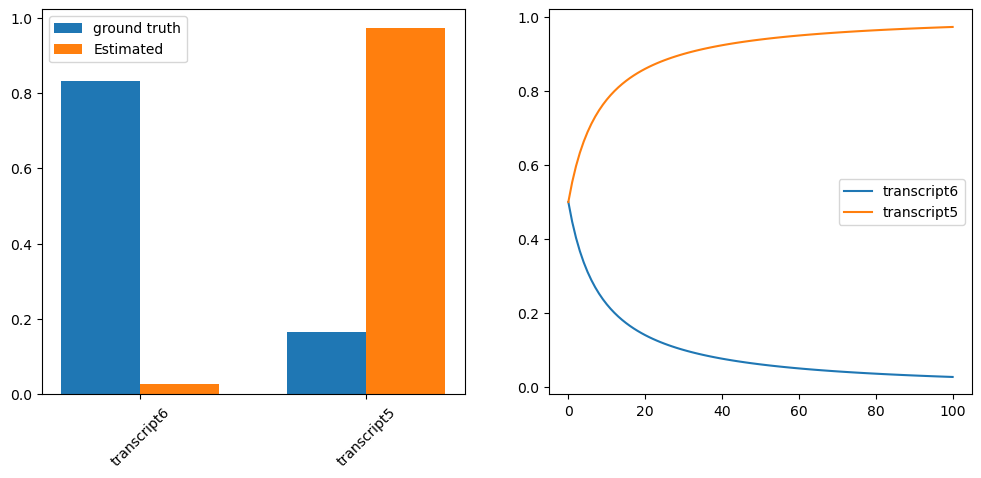

In [8]:
fig, axs = plt.subplots(len(oae.loci_set), 2, figsize=(12, 5*len(oae.loci_set)))


loci_list = list(oae.loci_set)
for i in range(len(loci_list)):
    ids = []
    true_activities = []
    estimated_activities = []
    activity_progression = []

    for region in loci_list[i].rgr_set:
        estimated_activities.append(region.average_activity)
        for id, rgr in ground_truth_rgrs.items():
            if rgr == region:
                true_activities.append(rgr.activity)
                ids.append(id)
                break
        if len(true_activities) < len(estimated_activities):
            true_activities.append(0)
            ids.append('0')

        
        axs[1].plot(loci_list[i].average_activities[region], label=ids[-1])
    axs[1].legend()
        

    estimated_activities = np.array(estimated_activities)
    estimated_activities = estimated_activities / estimated_activities.sum()
    true_activities = np.array(true_activities)
    true_activities = true_activities / true_activities.sum()

    bar_width = 0.35

    axs[0].bar([x-bar_width/2 for x in range(1,len(true_activities)+1)], true_activities, width=bar_width, label='ground truth')
    axs[0].bar([x+bar_width/2 for x in range(1,len(true_activities)+1)], estimated_activities, width=bar_width, label='Estimated')
    axs[0].legend()
    axs[0].set_xticks([x for x in range(1,len(true_activities)+1)], ids)
    for tick in axs[0].get_xticklabels():
        tick.set_rotation(45)



In [9]:
loc = loci_list[0]
for cg in loc.cgs[oae.ribo_seq_runs[0]]:
    print(cg)
    print(loc.cgs[oae.ribo_seq_runs[0]][cg].read_count)
    print(loc.cgs[oae.ribo_seq_runs[0]][cg].length)
    print()


frozenset({NOISE on region chr2:+:[999,2100):[2999,5000), NOISE on region chr2:+:[999,5000)})
7681
3102

frozenset({NOISE on region chr2:+:[999,5000)})
2301
899



In [10]:
loc = loci_list[0]
for eg in loc.egs[oae.ribo_seq_runs[0]]:
    print(eg)
    print(loc.egs[oae.ribo_seq_runs[0]][eg].read_count)
    print()

(frozenset({(NOISE on region chr2:+:[999,5000), None), (NOISE on region chr2:+:[999,2100):[2999,5000), None)}), 31, False)
1690

(frozenset({(NOISE on region chr2:+:[999,5000), None), (NOISE on region chr2:+:[999,2100):[2999,5000), None)}), 30, False)
1462

(frozenset({(NOISE on region chr2:+:[999,5000), None), (NOISE on region chr2:+:[999,2100):[2999,5000), None)}), 29, False)
894

(frozenset({(NOISE on region chr2:+:[999,5000), None), (NOISE on region chr2:+:[999,2100):[2999,5000), None)}), 32, False)
1132

(frozenset({(NOISE on region chr2:+:[999,5000), None), (NOISE on region chr2:+:[999,2100):[2999,5000), None)}), 30, True)
86

(frozenset({(NOISE on region chr2:+:[999,5000), None), (NOISE on region chr2:+:[999,2100):[2999,5000), None)}), 33, True)
82

(frozenset({(NOISE on region chr2:+:[999,5000), None), (NOISE on region chr2:+:[999,2100):[2999,5000), None)}), 33, False)
477

(frozenset({(NOISE on region chr2:+:[999,5000), None), (NOISE on region chr2:+:[999,2100):[2999,5000), No

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

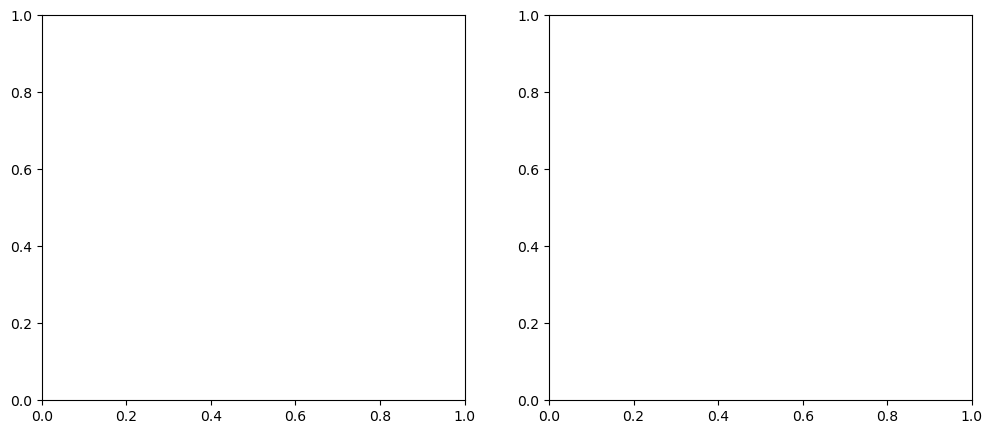

In [11]:
fig, axs = plt.subplots(len(oae.loci_set), 2, figsize=(12, 5*len(oae.loci_set)))


loci_list = list(oae.loci_set)
for i in range(len(loci_list)):
    ids = []
    true_activities = []
    estimated_activities = []
    activity_progression = []

    for region in loci_list[i].rgr_set:
        estimated_activities.append(region.average_activity)
        for id, rgr in ground_truth_rgrs.items():
            if rgr == region:
                true_activities.append(rgr.activity)
                ids.append(id)
                break
        if len(true_activities) < len(estimated_activities):
            true_activities.append(0)
            ids.append('0')

        
        axs[i,1].plot(loci_list[i].average_activities[region], label=ids[-1])
    axs[i,1].legend()
        

    estimated_activities = np.array(estimated_activities)
    estimated_activities = estimated_activities / estimated_activities.sum()
    true_activities = np.array(true_activities)
    true_activities = true_activities / true_activities.sum()

    bar_width = 0.35

    axs[i,0].bar([x-bar_width/2 for x in range(1,len(true_activities)+1)], true_activities, width=bar_width, label='ground truth')
    axs[i,0].bar([x+bar_width/2 for x in range(1,len(true_activities)+1)], estimated_activities, width=bar_width, label='Estimated')
    axs[i,0].legend()
    axs[i,0].set_xticks([x for x in range(1,len(true_activities)+1)], ids)
    for tick in axs[i,0].get_xticklabels():
        tick.set_rotation(45)




TypeError: 'Axes' object is not subscriptable

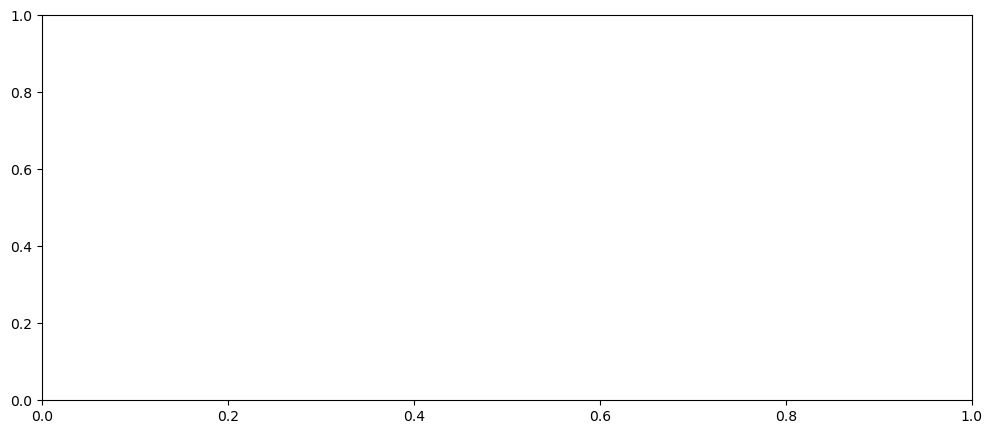

In [ ]:

fig, axs = plt.subplots(len(oae.loci_set), 1, figsize=(12, 5*len(oae.loci_set)))
for i in range(len(loci_list)):
    axs[i].plot(loci_list[i].lls)

IndexError: list index out of range

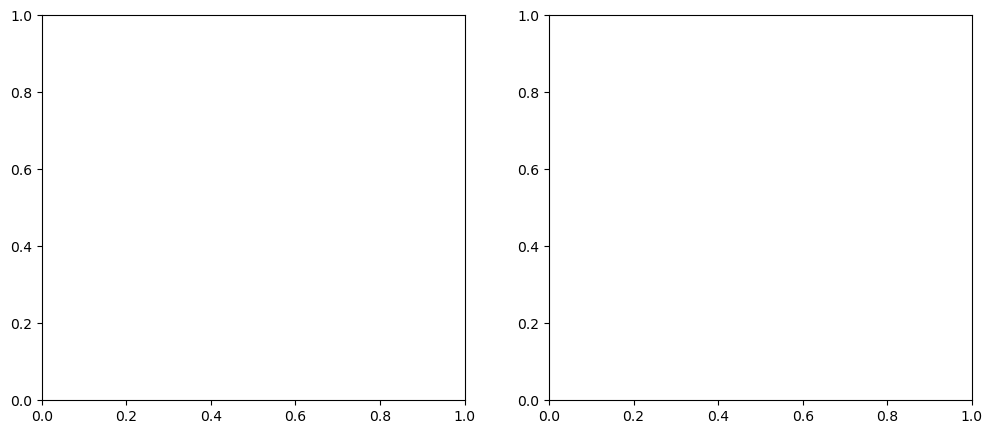

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))


loci_list = list(oae.loci_set)
i = 4
ids = []
true_activities = []
estimated_activities = []
activity_progression = []
for region in loci_list[i].rgr_set:
    estimated_activities.append(region.average_activity)
    for id, rgr in ground_truth_rgrs.items():
        if rgr == region:
            true_activities.append(rgr.activity)
            ids.append(id)
            break
    if len(true_activities) < len(estimated_activities):
        true_activities.append(0)
        ids.append('0')
    
    axs[1].plot(loci_list[i].average_activities[region], label=ids[-1])
axs[1].legend()
    
estimated_activities = np.array(estimated_activities)
estimated_activities = estimated_activities / estimated_activities.sum()
true_activities = np.array(true_activities)
true_activities = true_activities / true_activities.sum()
bar_width = 0.35
axs[0].bar([x-bar_width/2 for x in range(1,len(true_activities)+1)], true_activities, width=bar_width, label='ground truth')
axs[0].bar([x+bar_width/2 for x in range(1,len(true_activities)+1)], estimated_activities, width=bar_width, label='Estimated')
axs[0].legend()
axs[0].set_xticks([x for x in range(1,len(true_activities)+1)], ids)
for tick in axs[0].get_xticklabels():
    tick.set_rotation(45)

In [ ]:
loc = loci_list[4]
print(loc.incomplete_data_likelihood(oae.ribo_seq_runs))

noise_list = []

for noise in loc.rgr_set:
    if noise.type == 'NOISE':
        noise_list.append(noise)


#switch unscaled activities
for run in oae.ribo_seq_runs:
    noise_list[0].unscaled_activity[run], noise_list[1].unscaled_activity[run] = noise_list[1].unscaled_activity[run], noise_list[0].unscaled_activity[run]
    
print(loc.incomplete_data_likelihood(oae.ribo_seq_runs))

IndexError: list index out of range